# 06b — Router Training (Vision ON/OFF, New Dataset)

Train a **lightweight multimodal router** that selects the best VLM backend
for each (image, prompt) using the new `router_*_final.parquet` datasets.

**What this notebook does:**

1. Load prepared router datasets (train/val/test)  
2. Build `RouterDataset` and PyTorch DataLoaders  
3. Define `MultimodalRouterModel`:
   - Encoder-only transformer
   - Optional frozen CLIP vision encoder (controlled by `config.use_image`)  
4. Train with:
   - Hard labels (`router_best_model_id`)
   - Optional soft labels (`router_soft_p_*`) via KL loss  
   - Full W&B tracking (optional)  
5. Save best checkpoint  
6. Run a quick inference demo on random test samples

In [1]:
# Optional: install deps if needed (commented out)
# !pip install torch torchvision transformers datasets wandb seaborn matplotlib --upgrade

import os
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Optional, List, Dict, Tuple

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

import wandb

from transformers import AutoTokenizer, CLIPImageProcessor, CLIPModel

/home/hice1/vchopra37/scratch/projects/vlm_router/vlm_router_env/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
@dataclass
class RouterConfig:
    """Complete configuration for router training & logging."""
    
    # Paths
    data_root: Path = Path.cwd().parent.parent.parent / "dataset" / "final_dataset"  #/ "router_final"
    image_root: Path = Path.cwd().parent.parent.parent / "dataset" / "which_vlm_data" / "images"
    output_dir: Path = Path.cwd() / "router_training_outputs"
    checkpoint_dir: Path = Path.cwd() / "saved_output" / "router_checkpoints_final"
    
    # File names for router datasets
    train_file: str = "router_train_final.parquet"
    val_file: str   = "router_val_final.parquet"
    test_file: str  = "router_test_final.parquet"
    router_subdir: str = "router_final"   # data_root / router_subdir / train_file
    
    # Model architecture
    vision_encoder_name: str = "openai/clip-vit-base-patch32"  # Small CLIP
    text_tokenizer_name: str = "bert-base-uncased"
    d_model: int = 384
    num_layers: int = 4
    num_heads: int = 6
    ffn_dim: int = 1536
    dropout: float = 0.1
    max_text_length: int = 256
    
    # Vision usage
    use_image: bool = False          # <-- Toggle this to False for text-only router
    freeze_vision: bool = True      # Keep CLIP frozen by default
    
    # Training
    batch_size: int = 32
    num_epochs: int = 10
    learning_rate: float = 1e-4
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1
    gradient_clip_norm: float = 1.0
    
    # Loss configuration
    loss_type: str = "combined"  # "ce", "kl", or "combined"
    ce_weight: float = 0.5       # used if loss_type == "combined"
    kl_weight: float = 0.5
    label_smoothing: float = 0.0
    
    # Data loading
    num_workers: int = 4
    pin_memory: bool = True
    
    # Evaluation / logging
    eval_every_n_steps: int = 500   # optional, unused in simple loop
    save_every_n_steps: int = 1000  # optional, unused in simple loop
    log_every_n_steps: int = 50
    
    # W&B
    use_wandb: bool = True
    wandb_project: str = "vlm-router-training"
    wandb_entity: Optional[str] = None   # Set to your W&B user/org or leave None
    wandb_run_name: Optional[str] = "router_v2_with_vision"  # update for different runs
    
    # Device
    device: str = "cuda" if torch.cuda.is_available() else (
        "mps" if torch.backends.mps.is_available() else "cpu"
    )
    
    # Random seed
    seed: int = 42
    
    def __post_init__(self):
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)

# Instantiate config
config = RouterConfig()

# Set seeds
torch.manual_seed(config.seed)
np.random.seed(config.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.seed)

print("\n=== Configuration ===")
for k, v in asdict(config).items():
    print(f"{k:25s}: {v}")


=== Configuration ===
data_root                : /storage/ice1/1/0/vchopra37/projects/vlm_router/dataset/final_dataset
image_root               : /storage/ice1/1/0/vchopra37/projects/vlm_router/dataset/which_vlm_data/images
output_dir               : /storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_training_outputs
checkpoint_dir           : /storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/saved_output/router_checkpoints_final
train_file               : router_train_final.parquet
val_file                 : router_val_final.parquet
test_file                : router_test_final.parquet
router_subdir            : router_final
vision_encoder_name      : openai/clip-vit-base-patch32
text_tokenizer_name      : bert-base-uncased
d_model                  : 384
num_layers               : 4
num_heads                : 6
ffn_dim                  : 1536
dropout                  : 0.1
max_text_length          : 256
use_image               

In [3]:
print("Loading prepared router datasets...")

router_dir = config.data_root / config.router_subdir

train_df = pd.read_parquet(router_dir / config.train_file)
val_df   = pd.read_parquet(router_dir / config.val_file)
test_df  = pd.read_parquet(router_dir / config.test_file)

print("\nDataset sizes:")
print(f"  Train: {len(train_df):,}")
print(f"  Val:   {len(val_df):,}")
print(f"  Test:  {len(test_df):,}")

print("\nColumns (train) first 25:")
print(train_df.columns[:25].tolist())

# Sanity check: label column exists
assert "router_best_model_id" in train_df.columns, "router_best_model_id missing!"

Loading prepared router datasets...

Dataset sizes:
  Train: 63,963
  Val:   13,706
  Test:  13,707

Columns (train) first 25:
['sample_id', 'image_path', 'image_bytes_hash', 'prompt_raw', 'img_width', 'img_height', 'img_aspect_ratio', 'txt_prompt_length_chars', 'txt_prompt_length_words', 'router_task', 'source_dataset', 'source_config', 'txt_question_type', 'txt_has_mc_options', 'ground_truth', 'ground_truth_type', 'router_best_model_id', 'router_best_model_name', 'router_chosen_perf', 'router_chosen_cost', 'router_soft_p_deepseek_ocr', 'router_soft_p_qwen2_5_vl_3b', 'router_soft_p_qwen2_5_vl_7b', 'router_soft_p_qwen3_vl_8b_thinking', 'router_soft_p_gemma_3_27b']


In [4]:
# Detect model names from soft label columns or from param list
soft_label_prefix = "router_soft_p_"
soft_label_cols = [c for c in train_df.columns if c.startswith(soft_label_prefix)]

if len(soft_label_cols) > 0:
    model_names = [c[len(soft_label_prefix):] for c in soft_label_cols]
    print("\nDetected model names from soft label columns:")
    for i, m in enumerate(model_names):
        print(f"  {i}: {m}")
else:
    # Fallback: define manually based on your pipeline
    model_names = [
        "deepseek_ocr",
        "qwen2_5_vl_3b",
        "qwen2_5_vl_7b",
        "qwen3_vl_8b_thinking",
        "gemma_3_27b",
    ]
    print("\nUsing hard-coded model names:")
    for i, m in enumerate(model_names):
        print(f"  {i}: {m}")

num_models = len(model_names)

# Sanity check: label range
print("\nLabel stats:")
print(train_df["router_best_model_id"].value_counts().sort_index())
print(f"\nNum models inferred: {num_models}")
ID_TO_NAME = {i: name for i, name in enumerate(model_names)}
NAME_TO_ID = {name: i for i, name in ID_TO_NAME.items()}
NUM_MODELS = num_models



Detected model names from soft label columns:
  0: deepseek_ocr
  1: qwen2_5_vl_3b
  2: qwen2_5_vl_7b
  3: qwen3_vl_8b_thinking
  4: gemma_3_27b

Label stats:
router_best_model_id
0     2020
1    34665
2    17771
3      614
4     8893
Name: count, dtype: int64

Num models inferred: 5


## Quick Dataset Analysis


=== Label Distribution (Training Set) ===
router_best_model_name
qwen2_5_vl_3b           34665
qwen2_5_vl_7b           17771
gemma_3_27b              8893
deepseek_ocr             2020
qwen3_vl_8b_thinking      614
Name: count, dtype: int64

Fractions:
router_best_model_name
qwen2_5_vl_3b           0.541954
qwen2_5_vl_7b           0.277832
gemma_3_27b             0.139034
deepseek_ocr            0.031581
qwen3_vl_8b_thinking    0.009599
Name: count, dtype: float64


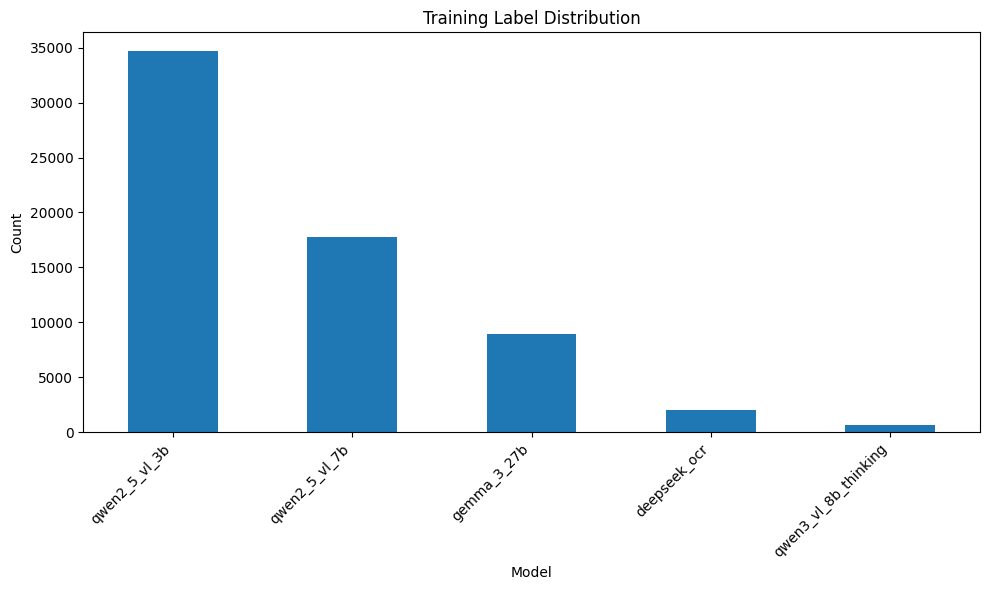

In [5]:
# Inspect label distribution
print("\n=== Label Distribution (Training Set) ===")
if "router_best_model_name" in train_df.columns:
    label_series = train_df["router_best_model_name"]
    label_dist = label_series.value_counts()
    labels_for_plot = label_dist.index.tolist()
else:
    label_series = train_df["router_best_model_id"]
    label_dist = label_series.value_counts().sort_index()
    labels_for_plot = [ID_TO_NAME.get(i, str(i)) for i in label_dist.index]

print(label_dist)
print("\nFractions:")
print(label_dist / len(train_df))

fig, ax = plt.subplots(figsize=(10, 6))
label_dist.plot(kind="bar", ax=ax)
ax.set_title("Training Label Distribution")
ax.set_xlabel("Model")
ax.set_ylabel("Count")
ax.set_xticklabels(labels_for_plot, rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Feature correlation snapshot

/home/hice1/vchopra37/scratch/models/tmp/ipykernel_2930401/3294192188.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_to_plot.values, y=corr_to_plot.index, ax=ax, palette="crest")


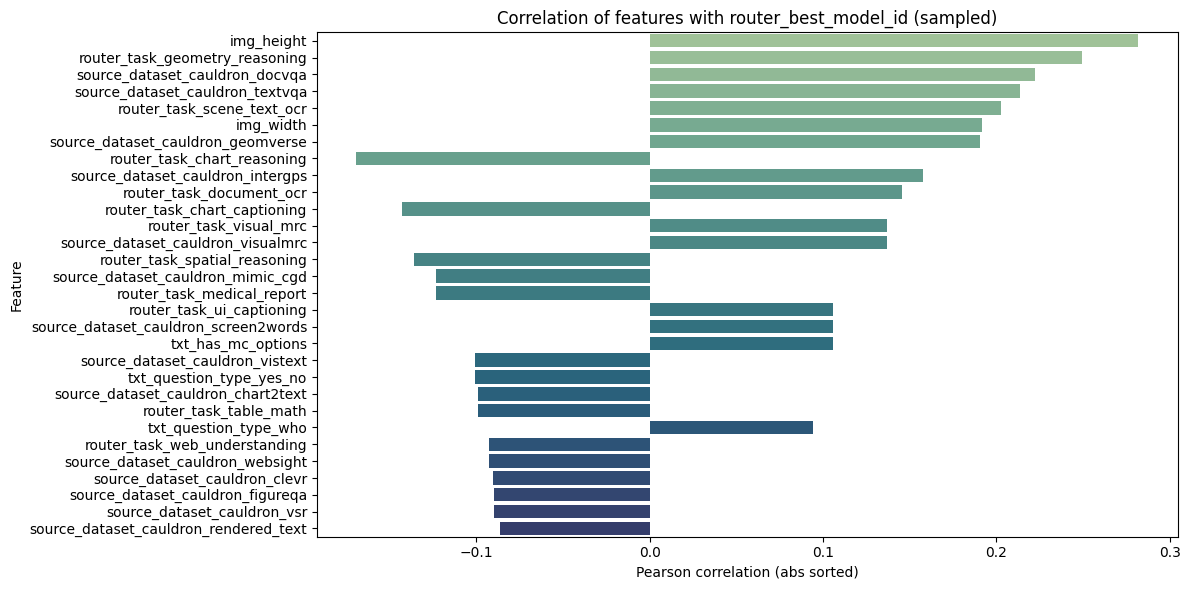

In [6]:
# Correlation snapshot across a small sample of training data
sample_size = min(5000, len(train_df))
feature_sample = train_df.sample(n=sample_size, random_state=42)

numeric_cols = [
    "img_width",
    "img_height",
    "img_aspect_ratio",
    "txt_prompt_length_chars",
    "txt_prompt_length_words",
]
binary_cols = ["txt_has_mc_options"]
categorical_cols = ["router_task", "source_dataset", "txt_question_type"]

available_numeric = [c for c in numeric_cols if c in feature_sample.columns]
available_binary = [c for c in binary_cols if c in feature_sample.columns]
available_cat = [c for c in categorical_cols if c in feature_sample.columns]

if len(available_numeric) + len(available_binary) + len(available_cat) == 0:
    print("No feature columns available for correlation snapshot.")
else:
    numeric_df = feature_sample[available_numeric].copy()
    numeric_df[available_binary] = feature_sample[available_binary].astype(float)

    cat_df = pd.get_dummies(
        feature_sample[available_cat],
        prefix=available_cat,
        dummy_na=True,
    )

    feature_matrix = pd.concat([numeric_df, cat_df], axis=1).fillna(0)

    corr = (
        feature_matrix.assign(target=feature_sample["router_best_model_id"])
        .corr(numeric_only=True)["target"]
        .drop("target")
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )

    top_n = 30
    corr_to_plot = corr.head(top_n)

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x=corr_to_plot.values, y=corr_to_plot.index, ax=ax, palette="crest")
    ax.set_title("Correlation of features with router_best_model_id (sampled)")
    ax.set_xlabel("Pearson correlation (abs sorted)")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()

    corr_to_plot.to_frame("correlation")


### Per-model correlation heatmap

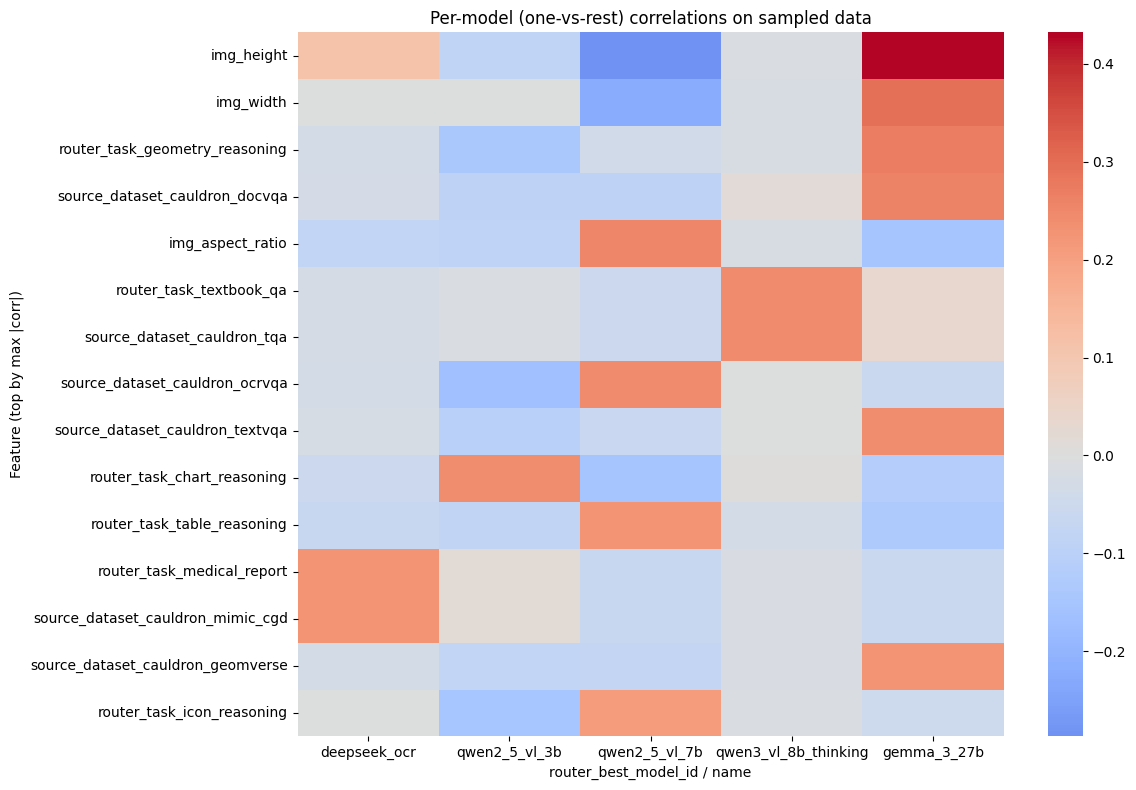

In [7]:
# One-vs-rest correlations by router target (per category)
try:
    feature_sample
    feature_matrix
except NameError:
    sample_size = min(5000, len(train_df))
    feature_sample = train_df.sample(n=sample_size, random_state=42)

    numeric_cols = [
        "img_width",
        "img_height",
        "img_aspect_ratio",
        "txt_prompt_length_chars",
        "txt_prompt_length_words",
    ]
    binary_cols = ["txt_has_mc_options"]
    categorical_cols = ["router_task", "source_dataset", "txt_question_type"]

    available_numeric = [c for c in numeric_cols if c in feature_sample.columns]
    available_binary = [c for c in binary_cols if c in feature_sample.columns]
    available_cat = [c for c in categorical_cols if c in feature_sample.columns]

    if len(available_numeric) + len(available_binary) + len(available_cat) == 0:
        feature_matrix = pd.DataFrame()
    else:
        numeric_df = feature_sample[available_numeric].copy()
        numeric_df[available_binary] = feature_sample[available_binary].astype(float)
        cat_df = pd.get_dummies(
            feature_sample[available_cat],
            prefix=available_cat,
            dummy_na=True,
        )
        feature_matrix = pd.concat([numeric_df, cat_df], axis=1).fillna(0)

if feature_matrix is None or feature_matrix.empty:
    print("No feature matrix available for per-model correlation heatmap.")
else:
    label_values = sorted(feature_sample["router_best_model_id"].unique())
    corr_by_label = {}
    for label in label_values:
        target = (feature_sample["router_best_model_id"] == label).astype(int)
        corr_series = (
            feature_matrix.assign(target=target)
            .corr(numeric_only=True)["target"]
            .drop("target")
        )
        corr_by_label[ID_TO_NAME.get(label, label)] = corr_series

    corr_df = pd.DataFrame(corr_by_label)
    if corr_df.empty:
        print("No correlation data available for per-model snapshot.")
    else:
        top_n = 15
        top_features = corr_df.abs().max(axis=1).sort_values(ascending=False).head(top_n).index
        corr_top = corr_df.loc[top_features]

        fig, ax = plt.subplots(figsize=(12, 8))
        sns.heatmap(corr_top, cmap="coolwarm", center=0, ax=ax)
        ax.set_title("Per-model (one-vs-rest) correlations on sampled data")
        ax.set_xlabel("router_best_model_id / name")
        ax.set_ylabel("Feature (top by max |corr|)")
        plt.tight_layout()
        plt.show()

        corr_top


In [8]:
class RouterDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        image_root: Path,
        image_processor: CLIPImageProcessor,
        tokenizer,
        config: RouterConfig,
        model_names: List[str],
    ):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.config = config
        self.model_names = model_names
        
        # Prepare soft label columns (if any)
        soft_label_prefix = "router_soft_p_"
        self.soft_label_cols = [f"{soft_label_prefix}{m}" for m in model_names if f"{soft_label_prefix}{m}" in df.columns]
        self.has_soft_labels = len(self.soft_label_cols) == len(model_names)
        
        # For quick stats
        print(f"RouterDataset: {len(self.df):,} samples, use_image={config.use_image}, soft_labels={self.has_soft_labels}")
    
    def __len__(self):
        return len(self.df)
    
    def _load_image(self, row) -> torch.Tensor:
        """Load image from disk (via image_path)."""
        img_path = row.get("image_path", None)
        if img_path is None or not isinstance(img_path, str):
            # Return a dummy image if missing
            pixel_values = torch.zeros(3, 224, 224)
            return pixel_values
        
        full_path = self.image_root / img_path
        if not full_path.exists():
            # Fallback: dummy
            pixel_values = torch.zeros(3, 224, 224)
            return pixel_values
        
        # Use CLIPImageProcessor to load & preprocess
        inputs = self.image_processor(images=str(full_path), return_tensors="pt")
        pixel_values = inputs["pixel_values"].squeeze(0)  # [3, H, W]
        return pixel_values
    
    def _build_router_text(self, row) -> str:
        """Combine metadata + prompt into a single text string."""
        prompt = row["prompt_raw"]
        w = row.get("img_width", None)
        h = row.get("img_height", None)
        ar = row.get("img_aspect_ratio", None)
        len_chars = row.get("txt_prompt_length_chars", None)
        len_words = row.get("txt_prompt_length_words", None)
        
        meta_parts = []
        if len_words is not None:
            meta_parts.append(f"PromptLenWords: {int(len_words)}.")
        if len_chars is not None:
            meta_parts.append(f"PromptLenChars: {int(len_chars)}.")
        if w is not None and h is not None:
            meta_parts.append(f"ImageWidth: {int(w)}. ImageHeight: {int(h)}.")
        if ar is not None:
            meta_parts.append(f"ImageAR: {float(ar):.2f}.")
        
        meta_str = " ".join(meta_parts)
        router_text = f"{meta_str} Question: {prompt}"
        return router_text
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # 1. Image
        if self.config.use_image:
            pixel_values = self._load_image(row)  # [3, H, W]
        else:
            pixel_values = torch.zeros(3, 224, 224)  # dummy to keep shape consistent
        
        # 2. Text
        router_text = self._build_router_text(row)
        encoding = self.tokenizer(
            router_text,
            padding="max_length",
            truncation=True,
            max_length=self.config.max_text_length,
            return_tensors="pt",
        )
        input_ids = encoding["input_ids"].squeeze(0)         # [T]
        attention_mask = encoding["attention_mask"].squeeze(0)  # [T]
        
        # 3. Labels
        label = int(row["router_best_model_id"])
        
        # 4. Soft labels
        if self.has_soft_labels:
            soft = row[self.soft_label_cols].to_numpy(dtype=np.float32)
            soft_labels = torch.from_numpy(soft)
        else:
            soft_labels = torch.zeros(len(self.model_names), dtype=torch.float32)
        
        sample = {
            "pixel_values": pixel_values,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "label": label,
            "soft_labels": soft_labels,
        }
        return sample

In [9]:
print("Loading image processor and tokenizer...")
image_processor = CLIPImageProcessor.from_pretrained(config.vision_encoder_name)
tokenizer = AutoTokenizer.from_pretrained(config.text_tokenizer_name)

print("\nCreating RouterDataset objects...")
train_dataset = RouterDataset(train_df, config.image_root, image_processor, tokenizer, config, model_names)
val_dataset   = RouterDataset(val_df,   config.image_root, image_processor, tokenizer, config, model_names)
test_dataset  = RouterDataset(test_df,  config.image_root, image_processor, tokenizer, config, model_names)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
    pin_memory=config.pin_memory,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=config.pin_memory,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=config.pin_memory,
)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Loading image processor and tokenizer...

Creating RouterDataset objects...
RouterDataset: 63,963 samples, use_image=False, soft_labels=True
RouterDataset: 13,706 samples, use_image=False, soft_labels=True
RouterDataset: 13,707 samples, use_image=False, soft_labels=True

Train batches: 1999
Val batches:   429
Test batches:  429


In [10]:
class MultimodalRouterModel(nn.Module):
    """Multimodal router: optional Vision + Text → logits over models."""
    
    def __init__(
        self,
        vision_encoder_name: str,
        text_tokenizer_name: str,
        num_models: int,
        d_model: int = 384,
        num_layers: int = 4,
        num_heads: int = 6,
        ffn_dim: int = 1536,
        dropout: float = 0.1,
        freeze_vision: bool = True,
        use_image: bool = True,
    ):
        super().__init__()
        
        self.use_image = use_image
        
        # Vision encoder (CLIP) if using image
        if use_image:
            print(f"Loading vision encoder: {vision_encoder_name}")
            self.vision_encoder = CLIPModel.from_pretrained(vision_encoder_name)
            if freeze_vision:
                for p in self.vision_encoder.parameters():
                    p.requires_grad = False
            vision_dim = self.vision_encoder.config.projection_dim
            self.vision_proj = nn.Linear(vision_dim, d_model)
        else:
            self.vision_encoder = None
            self.vision_proj = None
        
        # Text embedding (simple embedding + custom Transformer)
        print(f"Loading tokenizer: {text_tokenizer_name}")
        tokenizer = AutoTokenizer.from_pretrained(text_tokenizer_name)
        vocab_size = len(tokenizer)
        
        self.text_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(512, d_model)
        
        # CLS token
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=ffn_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Classification head
        self.classifier = nn.Linear(d_model, num_models)
        
        print("MultimodalRouterModel initialized.")
    
    def forward(
        self,
        pixel_values: torch.Tensor,   # [B, 3, H, W]
        input_ids: torch.Tensor,      # [B, T]
        attention_mask: torch.Tensor, # [B, T]
    ) -> torch.Tensor:
        batch_size = input_ids.size(0)
        
        # Vision
        if self.use_image and self.vision_encoder is not None:
            with torch.no_grad() if not any(p.requires_grad for p in self.vision_encoder.parameters()) else torch.enable_grad():
                vision_outputs = self.vision_encoder(pixel_values)
                vision_features = vision_outputs.pooler_output  # [B, vision_dim]
            vision_token = self.vision_proj(vision_features).unsqueeze(1)  # [B, 1, d_model]
        else:
            vision_token = None
        
        # Text
        text_emb = self.text_embedding(input_ids)  # [B, T, d_model]
        seq_length = text_emb.size(1)
        positions = torch.arange(seq_length, device=text_emb.device).unsqueeze(0).expand(batch_size, -1)
        text_emb = text_emb + self.position_embedding(positions)
        
        # Compose sequence: [CLS] (+ [VIMG]) + text
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)  # [B, 1, d_model]
        if vision_token is not None:
            sequence = torch.cat([cls_tokens, vision_token, text_emb], dim=1)  # [B, 2+T, d_model]
            # Build attention mask including CLS+VIMG
            extra_ones = torch.ones((batch_size, 2), dtype=attention_mask.dtype, device=attention_mask.device)
            full_mask = torch.cat([extra_ones, attention_mask], dim=1)  # [B, 2+T]
        else:
            sequence = torch.cat([cls_tokens, text_emb], dim=1)  # [B, 1+T, d_model]
            extra_ones = torch.ones((batch_size, 1), dtype=attention_mask.dtype, device=attention_mask.device)
            full_mask = torch.cat([extra_ones, attention_mask], dim=1)  # [B, 1+T]
        
        src_key_padding_mask = (full_mask == 0)  # True = ignore position
        
        hidden = self.transformer(sequence, src_key_padding_mask=src_key_padding_mask)
        cls_hidden = hidden[:, 0, :]
        logits = self.classifier(cls_hidden)
        
        return logits

print("MultimodalRouterModel class defined.")

MultimodalRouterModel class defined.


In [11]:
model = MultimodalRouterModel(
    vision_encoder_name=config.vision_encoder_name,
    text_tokenizer_name=config.text_tokenizer_name,
    num_models=num_models,
    d_model=config.d_model,
    num_layers=config.num_layers,
    num_heads=config.num_heads,
    ffn_dim=config.ffn_dim,
    dropout=config.dropout,
    freeze_vision=config.freeze_vision,
    use_image=config.use_image,
)

model = model.to(config.device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters:    {total_params:,}")
print(f"Trainable parameters:{trainable_params:,}")
print(f"Frozen parameters:   {total_params - trainable_params:,}")

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
)

scheduler = None  # Placeholder for future schedules

Loading tokenizer: bert-base-uncased


/home/hice1/vchopra37/scratch/projects/vlm_router/vlm_router_env/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


MultimodalRouterModel initialized.

Total parameters:    19,017,221
Trainable parameters:19,017,221
Frozen parameters:   0


In [12]:
def compute_losses(
    logits: torch.Tensor,
    labels: torch.Tensor,
    soft_labels: torch.Tensor,
    config: RouterConfig,
) -> Dict[str, torch.Tensor]:
    """Compute CE / KL / combined losses."""
    losses = {}
    
    # Cross-entropy with optional label smoothing
    if config.loss_type in ["ce", "combined"]:
        if config.label_smoothing > 0.0:
            num_classes = logits.size(-1)
            with torch.no_grad():
                true_dist = torch.zeros_like(logits)
                true_dist.fill_(config.label_smoothing / (num_classes - 1))
                true_dist.scatter_(1, labels.unsqueeze(1), 1.0 - config.label_smoothing)
            log_probs = F.log_softmax(logits, dim=-1)
            ce_loss = -(true_dist * log_probs).sum(dim=-1).mean()
        else:
            ce_loss = F.cross_entropy(logits, labels)
        losses["ce_loss"] = ce_loss
    
    # KL divergence to soft labels
    if config.loss_type in ["kl", "combined"] and soft_labels is not None and soft_labels.numel() > 0:
        log_probs = F.log_softmax(logits, dim=-1)
        kl_loss = F.kl_div(log_probs, soft_labels, reduction="batchmean")
        losses["kl_loss"] = kl_loss
    
    # Combine
    if config.loss_type == "ce":
        total = losses["ce_loss"]
    elif config.loss_type == "kl":
        total = losses["kl_loss"]
    else:  # combined
        total = config.ce_weight * losses.get("ce_loss", 0.0) +                 config.kl_weight * losses.get("kl_loss", 0.0)
    
    losses["total_loss"] = total
    return losses

In [13]:
def train_one_epoch(model, loader, optimizer, config: RouterConfig, epoch: int):
    model.train()
    device = config.device
    
    running_loss = 0.0
    running_ce = 0.0
    running_kl = 0.0
    running_correct = 0
    running_total = 0
    
    step = 0
    
    for batch in tqdm(loader, desc=f"Train epoch {epoch}", leave=False):
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        soft_labels = batch["soft_labels"].to(device)
        
        optimizer.zero_grad()
        
        logits = model(pixel_values, input_ids, attention_mask)
        preds = logits.argmax(dim=-1)
        
        # Normalize soft labels if present
        if soft_labels.sum(dim=-1).max() > 1.0 + 1e-3:
            soft_labels = soft_labels / (soft_labels.sum(dim=-1, keepdim=True) + 1e-8)
        
        losses = compute_losses(logits, labels, soft_labels, config)
        loss = losses["total_loss"]
        loss.backward()
        
        if config.gradient_clip_norm is not None and config.gradient_clip_norm > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip_norm)
        
        optimizer.step()
        
        running_loss += loss.item() * labels.size(0)
        running_ce += losses.get("ce_loss", torch.tensor(0.0)).item() * labels.size(0)
        running_kl += losses.get("kl_loss", torch.tensor(0.0)).item() * labels.size(0)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)
        
        step += 1
        if step % config.log_every_n_steps == 0:
            avg_loss = running_loss / running_total
            avg_acc = running_correct / running_total
            print(f"[Train] Step {step:5d} - AvgLoss: {avg_loss:.4f}, AvgAcc: {avg_acc:.4f}")
    
    epoch_loss = running_loss / running_total
    epoch_ce = running_ce / running_total
    epoch_kl = running_kl / running_total
    epoch_acc = running_correct / running_total
    
    metrics = {
        "loss": epoch_loss,
        "ce_loss": epoch_ce,
        "kl_loss": epoch_kl,
        "accuracy": epoch_acc,
    }
    return metrics


def eval_one_epoch(model, loader, config: RouterConfig, split_name: str = "val"):
    model.eval()
    device = config.device
    
    running_loss = 0.0
    running_ce = 0.0
    running_kl = 0.0
    running_correct = 0
    running_total = 0
    
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Eval ({split_name})", leave=False):
            pixel_values = batch["pixel_values"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            soft_labels = batch["soft_labels"].to(device)
            
            logits = model(pixel_values, input_ids, attention_mask)
            preds = logits.argmax(dim=-1)
            
            if soft_labels.sum(dim=-1).max() > 1.0 + 1e-3:
                soft_labels = soft_labels / (soft_labels.sum(dim=-1, keepdim=True) + 1e-8)
            
            losses = compute_losses(logits, labels, soft_labels, config)
            
            running_loss += losses["total_loss"].item() * labels.size(0)
            running_ce += losses.get("ce_loss", torch.tensor(0.0)).item() * labels.size(0)
            running_kl += losses.get("kl_loss", torch.tensor(0.0)).item() * labels.size(0)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)
            
            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
    
    epoch_loss = running_loss / running_total
    epoch_ce = running_ce / running_total
    epoch_kl = running_kl / running_total
    epoch_acc = running_correct / running_total
    
    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)
    
    metrics = {
        "loss": epoch_loss,
        "ce_loss": epoch_ce,
        "kl_loss": epoch_kl,
        "accuracy": epoch_acc,
        "labels": all_labels,
        "preds": all_preds,
    }
    return metrics

In [14]:
if config.use_wandb:
    wandb.init(
        project=config.wandb_project,
        entity=config.wandb_entity,
        name=config.wandb_run_name,
        config=asdict(config),
        tags=["router", "multimodal" if config.use_image else "text_only", "vlm"],
    )
    wandb.watch(model, log="all", log_freq=100)
    print(f"\nW&B run initialized: {wandb.run.name}")
    print(f"W&B URL: {wandb.run.url}")
else:
    print("\nW&B disabled (config.use_wandb = False)")

wandb: Currently logged in as: vedaangchopra (vedaangchopra_gatech) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



W&B run initialized: router_v2_with_vision
W&B URL: https://wandb.ai/vedaangchopra_gatech/vlm-router-training/runs/xhosgsz5



STARTING TRAINING

Epoch 1/10


Train epoch 1:   0%|          | 0/1999 [00:00<?, ?it/s]

[Train] Step    50 - AvgLoss: 0.7256, AvgAcc: 0.4913
[Train] Step   100 - AvgLoss: 0.6787, AvgAcc: 0.5537
[Train] Step   150 - AvgLoss: 0.6584, AvgAcc: 0.5817
[Train] Step   200 - AvgLoss: 0.6358, AvgAcc: 0.6058
[Train] Step   250 - AvgLoss: 0.6240, AvgAcc: 0.6191
[Train] Step   300 - AvgLoss: 0.6146, AvgAcc: 0.6298
[Train] Step   350 - AvgLoss: 0.6092, AvgAcc: 0.6370
[Train] Step   400 - AvgLoss: 0.6027, AvgAcc: 0.6445
[Train] Step   450 - AvgLoss: 0.5984, AvgAcc: 0.6504
[Train] Step   500 - AvgLoss: 0.5952, AvgAcc: 0.6537
[Train] Step   550 - AvgLoss: 0.5914, AvgAcc: 0.6590
[Train] Step   600 - AvgLoss: 0.5872, AvgAcc: 0.6641
[Train] Step   650 - AvgLoss: 0.5841, AvgAcc: 0.6677
[Train] Step   700 - AvgLoss: 0.5815, AvgAcc: 0.6707
[Train] Step   750 - AvgLoss: 0.5787, AvgAcc: 0.6745
[Train] Step   800 - AvgLoss: 0.5773, AvgAcc: 0.6767
[Train] Step   850 - AvgLoss: 0.5747, AvgAcc: 0.6798
[Train] Step   900 - AvgLoss: 0.5728, AvgAcc: 0.6815
[Train] Step   950 - AvgLoss: 0.5714, AvgAcc: 

Eval (val):   0%|          | 0/429 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ffe5109a200>
Traceback (most recent call last):
  File "/home/hice1/vchopra37/scratch/projects/vlm_router/vlm_router_env/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/home/hice1/vchopra37/scratch/projects/vlm_router/vlm_router_env/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/local/pace-apps/spack/packages/linux-rhel9-x86_64_v3/gcc-11.3.1/python-3.12.5-5sase6atfv2x5tf7dy5x5sqfzyguhsia/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ffe5109a200>
Traceback (most recent call last):
 

...

[Train] Step    50 - AvgLoss: 0.4236, AvgAcc: 0.8569


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ffe5109a200>
Traceback (most recent call last):
  File "/home/hice1/vchopra37/scratch/projects/vlm_router/vlm_router_env/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/home/hice1/vchopra37/scratch/projects/vlm_router/vlm_router_env/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/local/pace-apps/spack/packages/linux-rhel9-x86_64_v3/gcc-11.3.1/python-3.12.5-5sase6atfv2x5tf7dy5x5sqfzyguhsia/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7ffe5109a200>^
^Traceback (most recent call last):
^^  File "/home/hice1/vchopra37/scratch/projects/vlm_r

[Train] Step   100 - AvgLoss: 0.4204, AvgAcc: 0.8584
[Train] Step   150 - AvgLoss: 0.4195, AvgAcc: 0.8583
[Train] Step   200 - AvgLoss: 0.4212, AvgAcc: 0.8572
[Train] Step   250 - AvgLoss: 0.4190, AvgAcc: 0.8611
[Train] Step   300 - AvgLoss: 0.4212, AvgAcc: 0.8589
[Train] Step   350 - AvgLoss: 0.4223, AvgAcc: 0.8578
[Train] Step   400 - AvgLoss: 0.4230, AvgAcc: 0.8577
[Train] Step   450 - AvgLoss: 0.4229, AvgAcc: 0.8574
[Train] Step   500 - AvgLoss: 0.4231, AvgAcc: 0.8576
[Train] Step   550 - AvgLoss: 0.4226, AvgAcc: 0.8580
[Train] Step   600 - AvgLoss: 0.4230, AvgAcc: 0.8579
[Train] Step   650 - AvgLoss: 0.4240, AvgAcc: 0.8564
[Train] Step   700 - AvgLoss: 0.4235, AvgAcc: 0.8567
[Train] Step   750 - AvgLoss: 0.4239, AvgAcc: 0.8563
[Train] Step   800 - AvgLoss: 0.4242, AvgAcc: 0.8564
[Train] Step   850 - AvgLoss: 0.4247, AvgAcc: 0.8559
[Train] Step   900 - AvgLoss: 0.4254, AvgAcc: 0.8549
[Train] Step   950 - AvgLoss: 0.4252, AvgAcc: 0.8552
[Train] Step  1000 - AvgLoss: 0.4254, AvgAcc: 

Eval (val):   0%|          | 0/429 [00:00<?, ?it/s]


[Epoch 10] Train Loss: 0.4285, Train Acc: 0.8522
[Epoch 10] Val   Loss: 0.5189, Val   Acc: 0.7454

Training complete.
Best validation accuracy: 0.7631


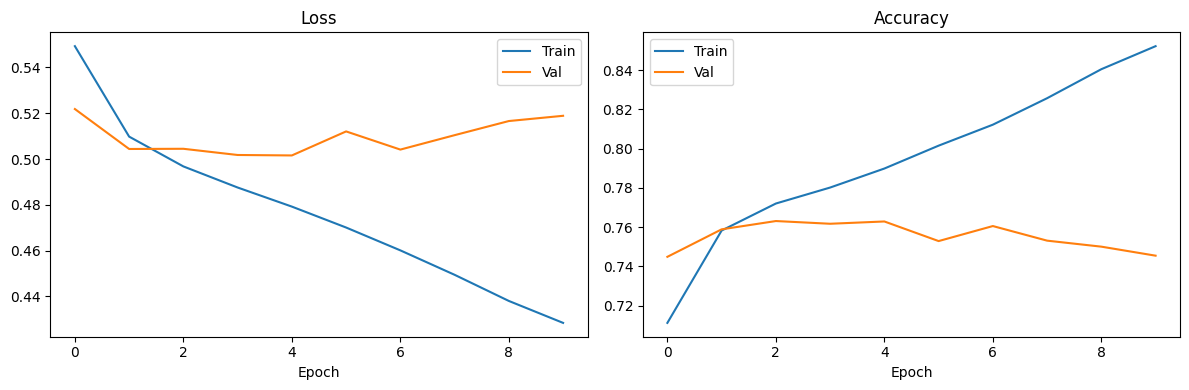

In [15]:
best_val_accuracy = 0.0
best_checkpoint_path = config.checkpoint_dir / "router_best.pt"

train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

for epoch in range(1, config.num_epochs + 1):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{config.num_epochs}")
    print(f"{'='*60}")
    
    train_metrics = train_one_epoch(model, train_loader, optimizer, config, epoch)
    val_metrics   = eval_one_epoch(model, val_loader, config, split_name="val")
    
    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accs.append(train_metrics["accuracy"])
    val_accs.append(val_metrics["accuracy"])
    
    print(f"\n[Epoch {epoch}] Train Loss: {train_metrics['loss']:.4f}, "
          f"Train Acc: {train_metrics['accuracy']:.4f}")
    print(f"[Epoch {epoch}] Val   Loss: {val_metrics['loss']:.4f}, "
          f"Val   Acc: {val_metrics['accuracy']:.4f}")
    
    if config.use_wandb:
        log_dict = {
            "train/epoch_loss": train_metrics["loss"],
            "train/epoch_accuracy": train_metrics["accuracy"],
            "val/epoch_loss": val_metrics["loss"],
            "val/epoch_accuracy": val_metrics["accuracy"],
        }
        if "ce_loss" in train_metrics:
            log_dict["train/epoch_ce_loss"] = train_metrics["ce_loss"]
            log_dict["val/ce_loss"] = val_metrics["ce_loss"]
        if "kl_loss" in train_metrics:
            log_dict["train/epoch_kl_loss"] = train_metrics["kl_loss"]
            log_dict["val/kl_loss"] = val_metrics["kl_loss"]
        wandb.log(log_dict, step=epoch * len(train_loader))
    
    # Save best
    if val_metrics["accuracy"] > best_val_accuracy:
        best_val_accuracy = val_metrics["accuracy"]
        print(f"\nNew best val accuracy: {best_val_accuracy:.4f} — saving checkpoint to {best_checkpoint_path}")
        torch.save({
            "model_state_dict": model.state_dict(),
            "config": asdict(config),
            "model_names": model_names,
        }, best_checkpoint_path)

print("\nTraining complete.")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")

# Simple training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, label="Train")
axes[0].plot(val_losses, label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(train_accs, label="Train")
axes[1].plot(val_accs, label="Val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
config.checkpoint_dir = Path.cwd() / "saved_output" / "router_checkpoints_final"
config.checkpoint_dir

PosixPath('/storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/saved_output/router_checkpoints_final')

In [17]:
best_checkpoint_path = config.checkpoint_dir / "router_best.pt"
best_checkpoint_path

PosixPath('/storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/saved_output/router_checkpoints_final/router_best.pt')


Evaluating best checkpoint on TEST set...


Eval (test):   0%|          | 0/429 [00:00<?, ?it/s]


Test Loss: 0.5030
Test Acc:  0.7657


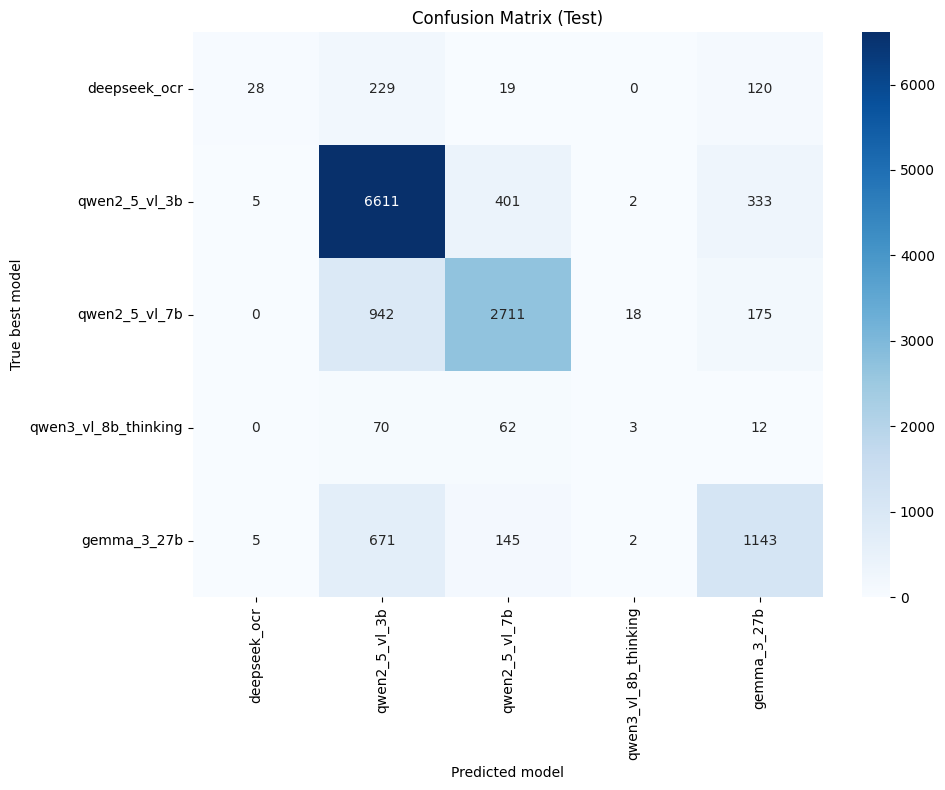

In [18]:
print("\nEvaluating best checkpoint on TEST set...")

# Reload best checkpoint (optional, but safer)
ckpt = torch.load(best_checkpoint_path, map_location=config.device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])

test_metrics = eval_one_epoch(model, test_loader, config, split_name="test")
test_labels = test_metrics["labels"]
test_preds = test_metrics["preds"]

print(f"\nTest Loss: {test_metrics['loss']:.4f}")
print(f"Test Acc:  {test_metrics['accuracy']:.4f}")

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=ax,
    xticklabels=model_names, yticklabels=model_names
)
ax.set_xlabel("Predicted model")
ax.set_ylabel("True best model")
ax.set_title("Confusion Matrix (Test)")
plt.tight_layout()

plt.savefig(config.output_dir / "test_confusion_matrix.png", dpi=150)
if config.use_wandb and wandb.run is not None:
    wandb.log({"test/accuracy": test_metrics["accuracy"], "test/confusion_matrix": wandb.Image(fig)})
    wandb.run.summary["test/accuracy"] = test_metrics["accuracy"]
plt.show()


In [19]:
# Simulate router performance using logged results
print("\n=== End-to-End Performance Analysis ===")
print("Simulating router routing decisions on test set...\n")

# Add predictions to test dataframe
test_df_eval = test_df.copy()
test_df_eval["router_predicted_model_id"] = test_preds
test_df_eval["router_predicted_model_name"] = [ID_TO_NAME.get(i, i) for i in test_preds]

router_perfs = []
router_costs = []

for _, row in test_df_eval.iterrows():
    pred_model_name = row["router_predicted_model_name"]

    perf_col = f"{pred_model_name}__sample_score"
    cost_col = f"{pred_model_name}__cost"

    router_perfs.append(row[perf_col] if perf_col in row.index and pd.notna(row[perf_col]) else 0.0)
    router_costs.append(row[cost_col] if cost_col in row.index and pd.notna(row[cost_col]) else 0.0)

if len(router_perfs) == 0:
    router_avg_perf = 0.0
    router_avg_cost = 0.0
    print("No router performance/cost data available.")
else:
    test_df_eval["router_actual_perf"] = router_perfs
    test_df_eval["router_actual_cost"] = router_costs

    router_avg_perf = test_df_eval["router_actual_perf"].mean()
    router_avg_cost = test_df_eval["router_actual_cost"].mean()

    print(f"Router average performance: {router_avg_perf:.4f}")
    print(f"Router average cost:        ${router_avg_cost:.6f}")

if config.use_wandb and wandb.run is not None:
    wandb.run.summary['test/router_avg_performance'] = router_avg_perf
    wandb.run.summary['test/router_avg_cost'] = router_avg_cost



=== End-to-End Performance Analysis ===
Simulating router routing decisions on test set...

Router average performance: 0.6246
Router average cost:        $0.000078


In [20]:
# Compare to baselines
print("\n=== Baseline Comparisons ===")

oracle_perf = test_df_eval.get('router_chosen_perf', pd.Series(dtype=float)).mean()
oracle_cost = test_df_eval.get('router_chosen_cost', pd.Series(dtype=float)).mean()
print(f"\nOracle (best per sample):")
print(f"  Avg performance: {oracle_perf:.4f}")
print(f"  Avg cost:        ${oracle_cost:.6f}")

baseline_results = []

for model_name in model_names:
    perf_col = f"{model_name}__sample_score"
    cost_col = f"{model_name}__cost"
    valid_col = f"{model_name}__valid_mask"

    valid_mask = test_df_eval[valid_col] if valid_col in test_df_eval.columns else [True] * len(test_df_eval)
    avg_perf = test_df_eval.loc[valid_mask, perf_col].mean() if perf_col in test_df_eval.columns else 0.0
    avg_cost = test_df_eval.loc[valid_mask, cost_col].mean() if cost_col in test_df_eval.columns else 0.0

    baseline_results.append({
        "strategy": f"Always {model_name}",
        "performance": avg_perf,
        "cost": avg_cost,
    })

    print(f"\nAlways {model_name}:")
    print(f"  Avg performance: {avg_perf:.4f}")
    print(f"  Avg cost:        ${avg_cost:.6f}")

baseline_results.append({
    "strategy": "Router (ours)",
    "performance": router_avg_perf,
    "cost": router_avg_cost,
})

baseline_results.append({
    "strategy": "Oracle (best per sample)",
    "performance": oracle_perf,
    "cost": oracle_cost,
})

baseline_df = pd.DataFrame(baseline_results)
print("\n=== Summary Table ===")
print(baseline_df.to_string(index=False))

if config.use_wandb and wandb.run is not None:
    wandb.log({'test/baseline_comparison': wandb.Table(dataframe=baseline_df)})



=== Baseline Comparisons ===

Oracle (best per sample):
  Avg performance: 0.6699
  Avg cost:        $0.064068

Always deepseek_ocr:
  Avg performance: 0.2871
  Avg cost:        $0.000025

Always qwen2_5_vl_3b:
  Avg performance: 0.6183
  Avg cost:        $0.000109

Always qwen2_5_vl_7b:
  Avg performance: 0.6208
  Avg cost:        $0.000221

Always qwen3_vl_8b_thinking:
  Avg performance: 0.4472
  Avg cost:        $0.000766

Always gemma_3_27b:
  Avg performance: 0.4263
  Avg cost:        $0.000048

=== Summary Table ===
                   strategy  performance     cost
        Always deepseek_ocr     0.287096 0.000025
       Always qwen2_5_vl_3b     0.618303 0.000109
       Always qwen2_5_vl_7b     0.620848 0.000221
Always qwen3_vl_8b_thinking     0.447204 0.000766
         Always gemma_3_27b     0.426271 0.000048
              Router (ours)     0.624570 0.000078
   Oracle (best per sample)     0.669867 0.064068


In [21]:
# Overall cost and accuracy summary
overall_accuracy = test_metrics["accuracy"]
total_router_cost = float(test_df_eval.get("router_actual_cost", pd.Series(dtype=float)).sum())
print(f"Overall test accuracy (top-1): {overall_accuracy:.4f}")
print(f"Total router cost: ${total_router_cost:.6f}")

if config.use_wandb and wandb.run is not None:
    wandb.run.summary["test/overall_accuracy"] = overall_accuracy
    wandb.run.summary["test/total_cost"] = total_router_cost


Overall test accuracy (top-1): 0.7657
Total router cost: $1.074285


/home/hice1/vchopra37/scratch/models/tmp/ipykernel_2930401/1688930707.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(strategies))


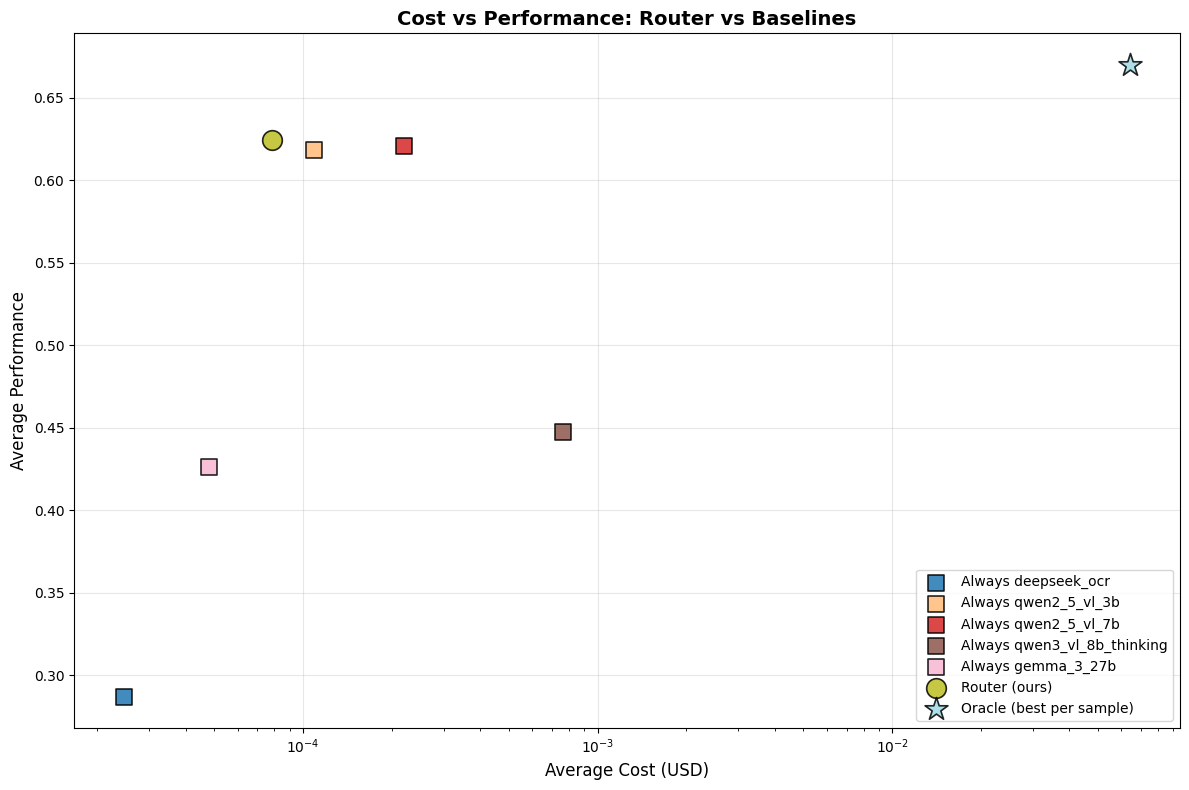

In [22]:
# Pareto plot: Cost vs Performance
if 'baseline_df' not in globals() or baseline_df.empty:
    print("No baseline data available for Pareto plot.")
else:
    fig, ax = plt.subplots(figsize=(12, 8))

    import matplotlib.cm as cm

    strategies = baseline_df['strategy'].unique()
    cmap = cm.get_cmap('tab20', len(strategies))
    strategy_to_color = {s: cmap(i) for i, s in enumerate(strategies)}

    for _, row in baseline_df.iterrows():
        strategy = row['strategy']

        if 'Router' in strategy:
            marker = 'o'
            size = 200
            zorder = 10
        elif 'Oracle' in strategy:
            marker = '*'
            size = 300
            zorder = 9
        else:
            marker = 's'
            size = 140
            zorder = 6

        color = strategy_to_color[strategy]

        ax.scatter(
            row['cost'],
            row['performance'],
            marker=marker,
            s=size,
            color=color,
            alpha=0.85,
            zorder=zorder,
            label=strategy,
            edgecolors='black',
            linewidths=1.2
        )

    ax.set_xlabel('Average Cost (USD)', fontsize=12)
    ax.set_ylabel('Average Performance', fontsize=12)
    ax.set_title('Cost vs Performance: Router vs Baselines', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), fontsize=10, loc='best')

    plt.tight_layout()

    if config.use_wandb and wandb.run is not None:
        wandb.log({'test/cost_vs_performance': wandb.Image(fig)})

    plt.savefig(config.output_dir / 'cost_vs_performance.png', dpi=150)
    plt.show()



=== Routing Patterns by Task ===


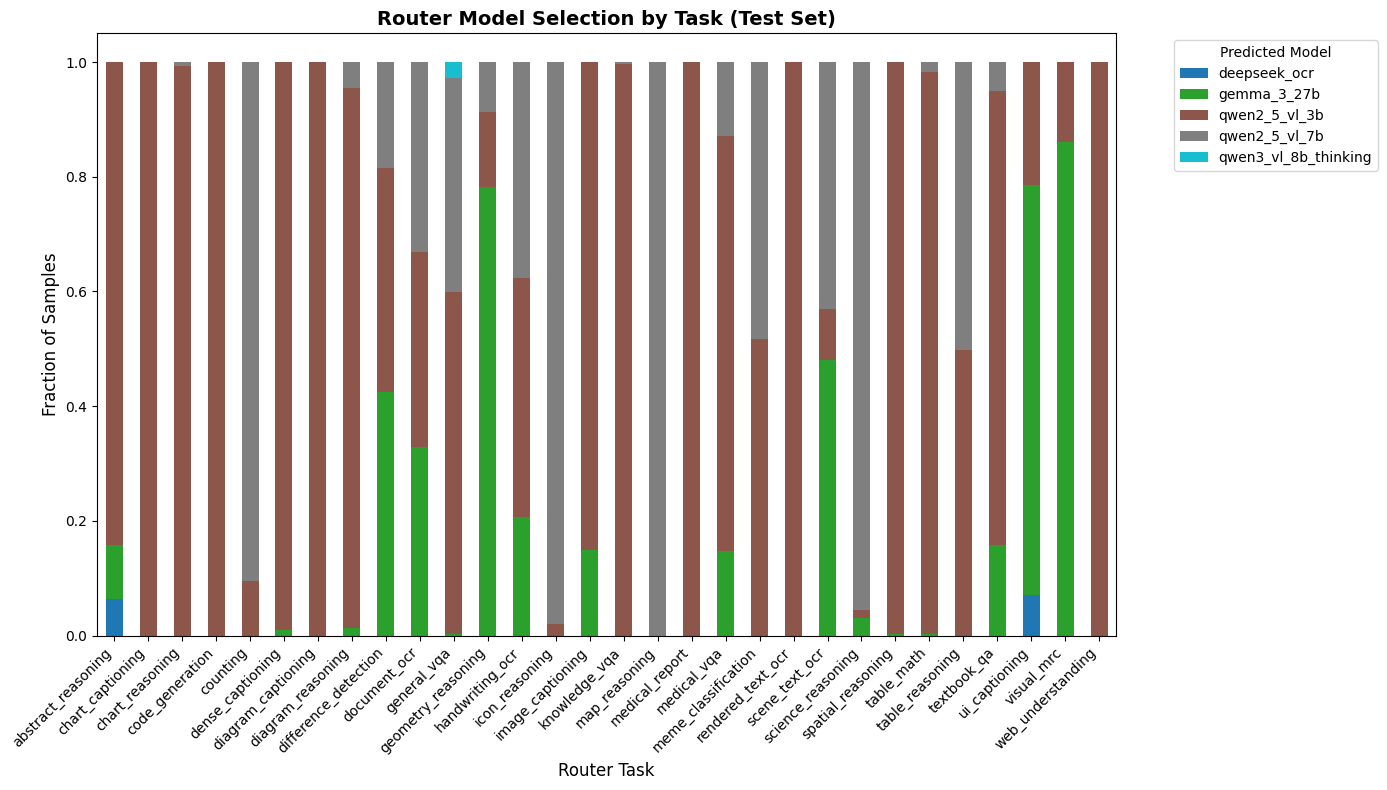

In [23]:
# Analyze routing patterns by task
if 'router_task' not in test_df_eval.columns:
    print("router_task column not present; skipping routing pattern analysis.")
else:
    print("\n=== Routing Patterns by Task ===")

    task_routing = (
        test_df_eval
        .groupby('router_task')['router_predicted_model_name']
        .value_counts(normalize=True)
        .rename('fraction')
        .reset_index()
    )

    task_routing_pivot = task_routing.pivot(
        index='router_task',
        columns='router_predicted_model_name',
        values='fraction'
    ).fillna(0)

    fig, ax = plt.subplots(figsize=(14, 8))
    task_routing_pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
    ax.set_xlabel('Router Task', fontsize=12)
    ax.set_ylabel('Fraction of Samples', fontsize=12)
    ax.set_title('Router Model Selection by Task (Test Set)', fontsize=14, fontweight='bold')
    ax.legend(title='Predicted Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if config.use_wandb and wandb.run is not None:
        wandb.log({'test/routing_by_task': wandb.Image(fig)})

    plt.savefig(config.output_dir / 'routing_by_task.png', dpi=150)
    plt.show()

    if config.use_wandb and wandb.run is not None:
        wandb.log({'test/routing_by_task_table': wandb.Table(dataframe=task_routing)})



=== Overall Routing Distribution (Test Set) ===
router_predicted_model_name
qwen2_5_vl_3b           8523
qwen2_5_vl_7b           3338
gemma_3_27b             1783
deepseek_ocr              38
qwen3_vl_8b_thinking      25
Name: count, dtype: int64

Fractions:
router_predicted_model_name
qwen2_5_vl_3b           0.621799
qwen2_5_vl_7b           0.243525
gemma_3_27b             0.130080
deepseek_ocr            0.002772
qwen3_vl_8b_thinking    0.001824
Name: count, dtype: float64


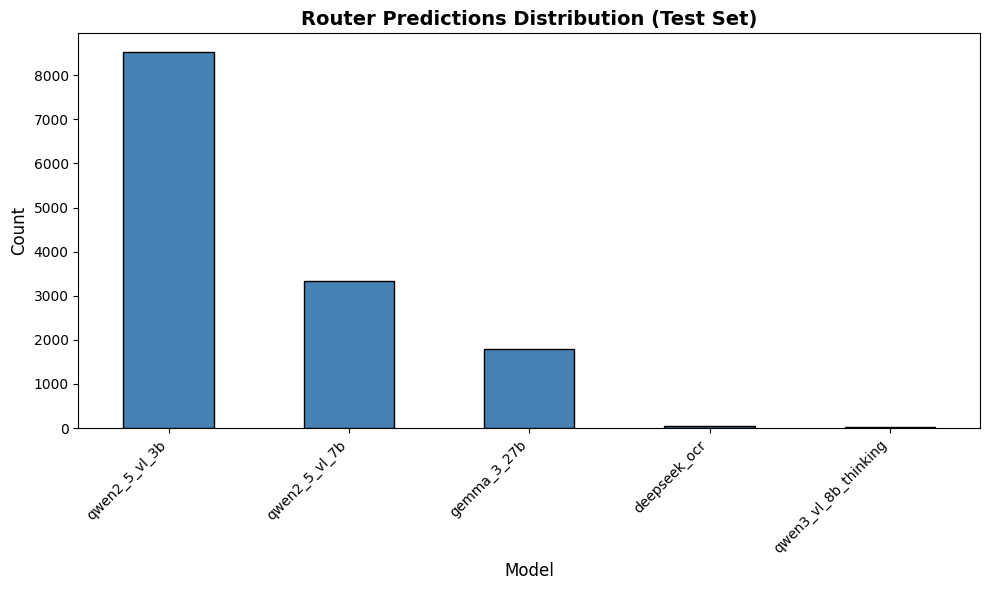

In [24]:
# Routing distribution overall
routing_dist = test_df_eval['router_predicted_model_name'].value_counts()

print("\n=== Overall Routing Distribution (Test Set) ===")
print(routing_dist)
print("\nFractions:")
print(routing_dist / len(test_df_eval))

fig, ax = plt.subplots(figsize=(10, 6))
routing_dist.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Router Predictions Distribution (Test Set)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

if config.use_wandb and wandb.run is not None:
    wandb.log({'test/routing_distribution': wandb.Image(fig)})

plt.savefig(config.output_dir / 'routing_distribution.png', dpi=150)
plt.show()


In [25]:
# Save test predictions
test_predictions_path = config.output_dir / 'test_predictions.parquet'
test_df_eval[[
    'sample_id',
    'router_task',
    'source_dataset',
    'router_best_model_name' if 'router_best_model_name' in test_df_eval.columns else 'router_best_model_id',
    'router_predicted_model_name',
    'router_chosen_perf' if 'router_chosen_perf' in test_df_eval.columns else None,
    'router_actual_perf' if 'router_actual_perf' in test_df_eval.columns else None,
    'router_chosen_cost' if 'router_chosen_cost' in test_df_eval.columns else None,
    'router_actual_cost' if 'router_actual_cost' in test_df_eval.columns else None,
]].dropna(axis=1, how='all').to_parquet(test_predictions_path, index=False)

print(f"\nTest predictions saved to: {test_predictions_path}")

if config.use_wandb and wandb.run is not None:
    artifact = wandb.Artifact(
        name=f'test-predictions-{wandb.run.id}',
        type='predictions',
        description='Test set predictions with performance and cost',
    )
    artifact.add_file(str(test_predictions_path))
    wandb.log_artifact(artifact)



Test predictions saved to: /storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_training_outputs/test_predictions.parquet


In [26]:
# Final summary
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"\nBest validation accuracy:     {best_val_accuracy:.4f}")
print(f"Test accuracy (top-1):        {test_metrics['accuracy']:.4f}")
print(f"\nRouter avg performance:       {router_avg_perf:.4f}")
print(f"Router avg cost:              ${router_avg_cost:.6f}")
print(f"\nOracle avg performance:       {oracle_perf:.4f}")
print(f"Oracle avg cost:              ${oracle_cost:.6f}")
print(f"\nPerformance gap to oracle:    {(oracle_perf - router_avg_perf):.4f}")
print(f"Cost savings vs oracle:       ${(oracle_cost - router_avg_cost):.6f}")

print(f"\nCheckpoints saved to: {config.checkpoint_dir}")
print(f"Outputs saved to: {config.output_dir}")
if config.use_wandb and wandb.run is not None:
    print(f"W&B run: {wandb.run.url}")

print("\n" + "="*60)
print("ALL DONE!")
print("="*60)



TRAINING SUMMARY

Best validation accuracy:     0.7631
Test accuracy (top-1):        0.7657

Router avg performance:       0.6246
Router avg cost:              $0.000078

Oracle avg performance:       0.6699
Oracle avg cost:              $0.064068

Performance gap to oracle:    0.0453
Cost savings vs oracle:       $0.063990

Checkpoints saved to: /storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/saved_output/router_checkpoints_final
Outputs saved to: /storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_training_outputs
W&B run: https://wandb.ai/vedaangchopra_gatech/vlm-router-training/runs/xhosgsz5

ALL DONE!


In [27]:
import random
from IPython.display import display, Image as IPyImage

def router_infer_demo(
    model,
    df: pd.DataFrame,
    num_samples: int = 5,
    show_images: bool = True,
):
    model.eval()
    device = config.device
    
    indices = random.sample(range(len(df)), k=min(num_samples, len(df)))
    subset = df.iloc[indices]
    
    for i, row in subset.iterrows():
        print("\n" + "-"*80)
        print(f"sample_id: {row['sample_id']}")
        print(f"source_dataset: {row.get('source_dataset', 'N/A')}")
        print(f"router_task: {row.get('router_task', 'N/A')}")
        print(f"Ground truth best model: {model_names[row['router_best_model_id']]}")

        if show_images and isinstance(row.get('image_path', None), str):
            img_path = config.image_root / row['image_path']
            if img_path.exists():
                display(IPyImage(filename=str(img_path)))
        
        print(f"\nPrompt:\n{row['prompt_raw']}\n")
        
        # Use dataset to reconstruct sample
        idx_in_dataset = subset.index.get_loc(i)
        sample = test_dataset[idx_in_dataset]
        
        pixel_values = sample["pixel_values"].unsqueeze(0).to(device)
        input_ids = sample["input_ids"].unsqueeze(0).to(device)
        attention_mask = sample["attention_mask"].unsqueeze(0).to(device)
        
        with torch.no_grad():
            logits = model(pixel_values, input_ids, attention_mask)
            probs = F.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
            pred_id = int(probs.argmax())
        
        print(f"Router prediction: {model_names[pred_id]}")
        print("Probabilities:")
        for j, m in enumerate(model_names):
            print(f"  {m:25s}: {probs[j]:.3f}")

# Run demo
router_infer_demo(model, test_df, num_samples=5, show_images=False)


--------------------------------------------------------------------------------
sample_id: cocoqa_01451_c58bc880b593099b
source_dataset: cauldron_cocoqa
router_task: general_vqa
Ground truth best model: qwen2_5_vl_3b

Prompt:
Overripe what on plates with breakfast food packages
Quick response, please.

Router prediction: qwen2_5_vl_3b
Probabilities:
  deepseek_ocr             : 0.009
  qwen2_5_vl_3b            : 0.609
  qwen2_5_vl_7b            : 0.172
  qwen3_vl_8b_thinking     : 0.027
  gemma_3_27b              : 0.183

--------------------------------------------------------------------------------
sample_id: vsr_00063_6fdf60d8ebd0686c
source_dataset: cauldron_vsr
router_task: spatial_reasoning
Ground truth best model: qwen2_5_vl_3b

Prompt:
Does the caption "The hot dog is parallel to the bus." correctly depict the image?
Answer yes or no.

Router prediction: qwen2_5_vl_3b
Probabilities:
  deepseek_ocr             : 0.059
  qwen2_5_vl_3b            : 0.413
  qwen2_5_vl_7b        

In [28]:
# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, test_preds, labels=range(num_models)
)

per_class_df = pd.DataFrame({
    "model": model_names,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support,
})

print("\n=== Per-Class Metrics (Test Set) ===")
print(per_class_df.to_string(index=False))

if config.use_wandb and wandb.run is not None:
    wandb.log({'test/per_class_metrics': wandb.Table(dataframe=per_class_df)})




=== Per-Class Metrics (Test Set) ===
               model  precision   recall       f1  support
        deepseek_ocr   0.736842 0.070707 0.129032      396
       qwen2_5_vl_3b   0.775666 0.899211 0.832882     7352
       qwen2_5_vl_7b   0.812163 0.704888 0.754733     3846
qwen3_vl_8b_thinking   0.120000 0.020408 0.034884      147
         gemma_3_27b   0.641054 0.581384 0.609763     1966


In [30]:
# Per-class accuracy diagnostics
per_class_acc = []
for cid in range(num_models):
    mask = (test_labels == cid)
    if mask.sum() == 0:
        per_class_acc.append(np.nan)
    else:
        per_class_acc.append((test_preds[mask] == test_labels[mask]).mean())

balanced_acc = np.nanmean(per_class_acc)
print(f"Overall acc   : {overall_accuracy:.4f}")
print(f"Balanced acc  : {balanced_acc:.4f}")

for cid, acc in enumerate(per_class_acc):
    print(f"  {model_names[cid]:<25}  acc_when_best = {acc:.3f}")

if config.use_wandb:
    wandb.log({
        "test/overall_acc": overall_accuracy,
        "test/balanced_acc": balanced_acc,
        **{f"test/class_acc/{model_names[i]}": per_class_acc[i] for i in range(num_models)},
    })



Overall acc   : 0.7657
Balanced acc  : 0.4553
  deepseek_ocr               acc_when_best = 0.071
  qwen2_5_vl_3b              acc_when_best = 0.899
  qwen2_5_vl_7b              acc_when_best = 0.705
  qwen3_vl_8b_thinking       acc_when_best = 0.020
  gemma_3_27b                acc_when_best = 0.581


In [31]:
if config.use_wandb:
    wandb.finish()
    print("\nW&B run finished.")
else:
    print("\nW&B was disabled; nothing to finish.")

test/accuracy,▁
test/balanced_acc,▁
test/class_acc/deepseek_ocr,▁
test/class_acc/gemma_3_27b,▁
test/class_acc/qwen2_5_vl_3b,▁
test/class_acc/qwen2_5_vl_7b,▁
test/class_acc/qwen3_vl_8b_thinking,▁
test/overall_acc,▁
train/epoch_accuracy,▁▃▄▄▅▅▆▇▇█
train/epoch_ce_loss,█▆▅▅▄▄▃▂▂▁
+6,...



W&B run finished.
